In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv


In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv')

In [5]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [7]:
df = df.drop(['id'] , axis = 1) 


In [8]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [10]:
X_train.shape

(46916, 11)

In [11]:
X_test.shape

(11729, 11)

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46916 entries, 14337 to 56422
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  46916 non-null  int64  
 1   person_income               46916 non-null  int64  
 2   person_home_ownership       46916 non-null  object 
 3   person_emp_length           46916 non-null  float64
 4   loan_intent                 46916 non-null  object 
 5   loan_grade                  46916 non-null  object 
 6   loan_amnt                   46916 non-null  int64  
 7   loan_int_rate               46916 non-null  float64
 8   loan_percent_income         46916 non-null  float64
 9   cb_person_default_on_file   46916 non-null  object 
 10  cb_person_cred_hist_length  46916 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 4.3+ MB


In [13]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11729 entries, 4657 to 23520
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  11729 non-null  int64  
 1   person_income               11729 non-null  int64  
 2   person_home_ownership       11729 non-null  object 
 3   person_emp_length           11729 non-null  float64
 4   loan_intent                 11729 non-null  object 
 5   loan_grade                  11729 non-null  object 
 6   loan_amnt                   11729 non-null  int64  
 7   loan_int_rate               11729 non-null  float64
 8   loan_percent_income         11729 non-null  float64
 9   cb_person_default_on_file   11729 non-null  object 
 10  cb_person_cred_hist_length  11729 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 1.1+ MB


In [14]:
X_train.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [15]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 46916 entries, 14337 to 56422
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
46916 non-null  int64
dtypes: int64(1)
memory usage: 733.1 KB


In [16]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 11729 entries, 4657 to 23520
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
11729 non-null  int64
dtypes: int64(1)
memory usage: 183.3 KB


In [17]:
X_train['person_age'].skew()

np.float64(1.989851611686517)

<Axes: xlabel='person_age'>

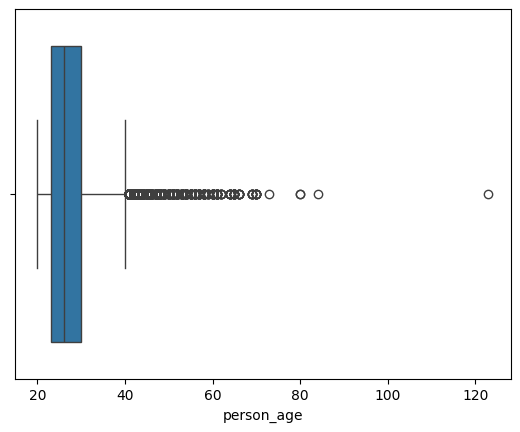

In [18]:
sns.boxplot(x=X_train['person_age'])

<Axes: xlabel='person_age', ylabel='Count'>

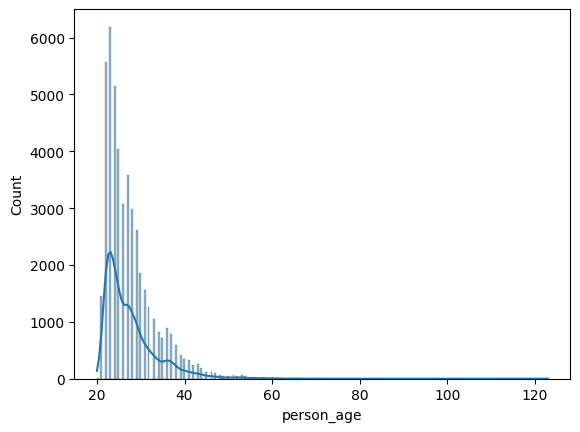

In [19]:
sns.histplot(data=X_train, x='person_age', kde=True)

<Axes: ylabel='Density'>

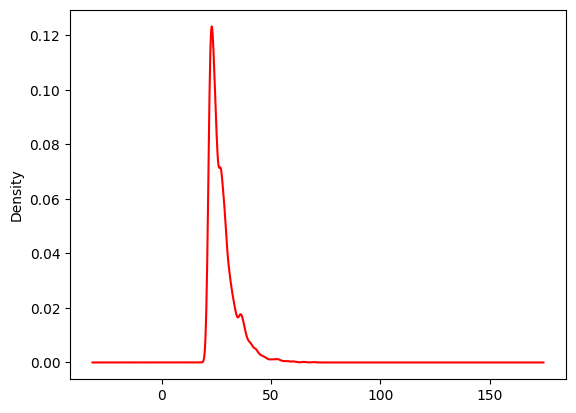

In [20]:
X_train['person_age'].plot(kind='kde', color='red')

In [21]:
# ── IQR Method ────────────────────────────────────────────────────
Q1 = X_train['person_age'].quantile(0.25)
Q3 = X_train['person_age'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

mask = (
    (X_train['person_age'] >= lower_iqr) &
    (X_train['person_age'] <= upper_iqr)
)

X_train = X_train[mask].copy()
y_train = y_train[mask].copy()

In [22]:
# Q1 = X_test['person_age'].quantile(0.25)
# Q3 = X_test['person_age'].quantile(0.75)
# IQR = Q3 - Q1

# lower_iqr = Q1 - 1.5 * IQR
# upper_iqr = Q3 + 1.5 * IQR

# mask = (
#     (X_test['person_age'] >= lower_iqr) &
#     (X_test['person_age'] <= upper_iqr)
# )

# X_test = X_test[mask].copy()
# y_test = y_test[mask].copy()

In [23]:
X_train['person_age'].skew()

np.float64(0.9991391406195866)

In [24]:
# person_income 
X_train['person_income'].skew()

np.float64(11.825576993081079)

<Axes: xlabel='person_income', ylabel='Count'>

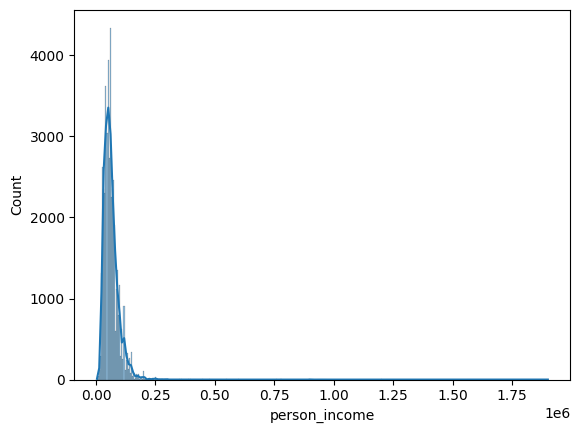

In [25]:
sns.histplot(data=X_train, x='person_income', kde=True)

<Axes: ylabel='Density'>

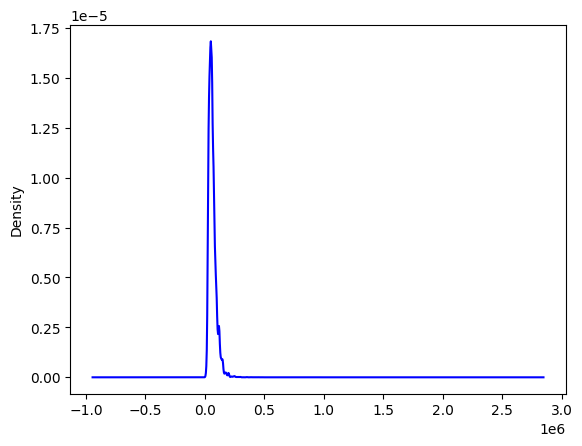

In [26]:
X_train['person_income'].plot(kind='kde', color='blue')

In [27]:
# X_train_log_person_income = X_train.copy()
X_train['person_income'] = np.log1p(X_train['person_income'])
X_test['person_income'] = np.log1p(X_test['person_income'])

In [28]:
X_train['person_income'].skew()

np.float64(0.21987424514896567)

<Axes: xlabel='person_income', ylabel='Count'>

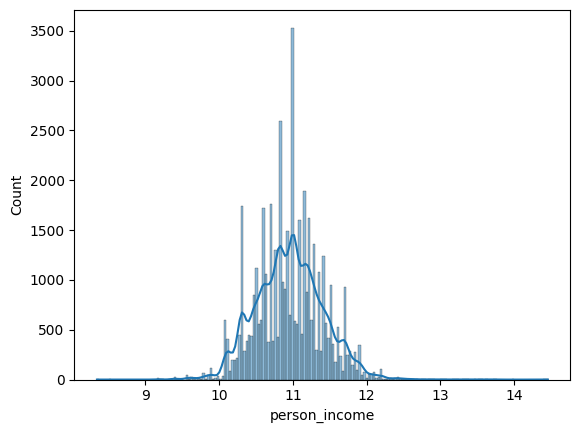

In [29]:
#sns.histplot(data=X_train_log_person_income, x='person_income', kde=True)
sns.histplot(data=X_train, x='person_income', kde=True)

In [30]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # ── Before vs After on same plot (left) ───────────────────────────
# X_train['person_income'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
# X_train_log_person_income['person_income'].plot(kind='kde', ax=axes[0], color='red', label='After Log')

# axes[0].set_title('person_income: Before vs After Log')
# axes[0].set_xlabel('person_income')
# axes[0].set_ylabel('Density')
# lines, labels = axes[0].get_legend_handles_labels()
# axes[0].legend(lines, labels, loc='best')

# # ── Boxplot to see outlier removal (right) ────────────────────────
# axes[1].boxplot(
#     [X_train['person_income'], X_train_log_person_income['person_income']],
#     labels=['Before', 'After Log'],
#     patch_artist=True,
#     boxprops=dict(facecolor='lightblue'),
# )
# axes[1].set_title('Boxplot: Before vs After Log')

# plt.tight_layout()
# plt.show()

In [31]:
# person_home_ownership 
X_train['person_home_ownership'].value_counts(dropna = False)

person_home_ownership
RENT        23524
MORTGAGE    18982
OWN          2400
OTHER          64
Name: count, dtype: int64

In [32]:
X_train = pd.get_dummies(X_train,columns=['person_home_ownership'],drop_first=True,dtype=int) 
X_test = pd.get_dummies(X_test,columns=['person_home_ownership'],drop_first=True,dtype=int)

In [33]:
X_train.head()

,person_age,person_income,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
14337,36,10.819798,0.0,HOMEIMPROVEMENT,C,7200,13.85,0.14,Y,15,0,0,1
17117,27,10.673619,3.0,DEBTCONSOLIDATION,C,5000,11.66,0.12,Y,9,0,0,1
32590,25,11.156265,0.0,EDUCATION,A,8000,7.88,0.11,N,3,0,0,0
55811,39,11.225257,2.0,DEBTCONSOLIDATION,A,15000,6.54,0.20,N,11,0,0,0
40120,22,10.727685,5.0,MEDICAL,A,4000,7.66,0.09,N,2,0,0,1


In [34]:
# person_emp_length 
X_train['person_emp_length'].skew()

np.float64(2.234067487113618)

<Axes: xlabel='person_emp_length', ylabel='Count'>

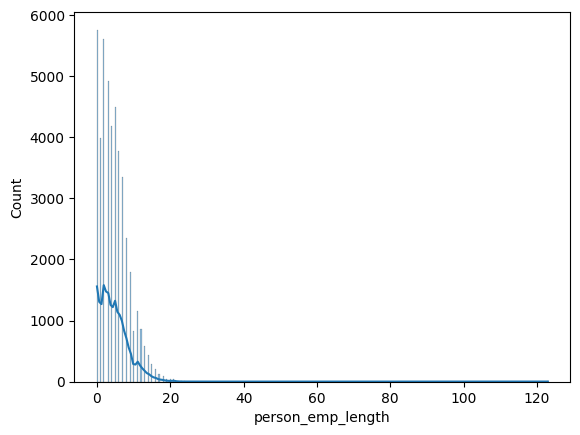

In [35]:
sns.histplot(data=X_train, x='person_emp_length', kde=True)

In [36]:
# X_train['person_emp_length'] = np.sqrt(X_train['person_emp_length'])
# # np.float64(-0.2178503548128392)

In [37]:
z_scores = np.abs(stats.zscore(X_train['person_emp_length']))
z_scores = np.abs(stats.zscore(X_train['person_emp_length']))
X_train = X_train[z_scores < 3].copy()

In [38]:
# z_scores = np.abs(stats.zscore(X_test['person_emp_length']))
# z_scores = np.abs(stats.zscore(X_test['person_emp_length']))
# X_test = X_test[z_scores < 3].copy()

<Axes: xlabel='person_emp_length', ylabel='Count'>

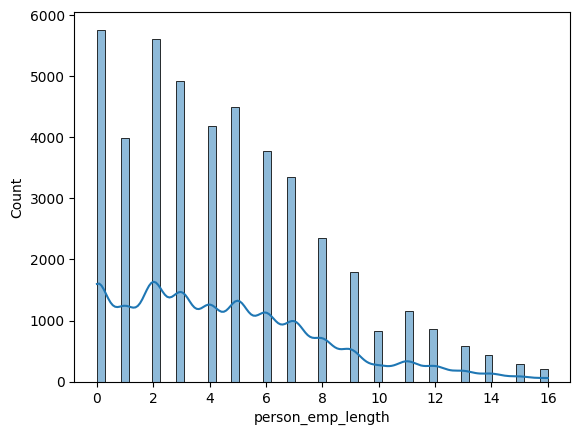

In [39]:
# sns.histplot(data=X_train_zscore, x='person_emp_length', kde=True)
sns.histplot(data=X_train, x='person_emp_length', kde=True)

In [40]:
X_train['person_emp_length'].skew()

np.float64(0.8000827788242794)

<Axes: xlabel='loan_intent', ylabel='Count'>

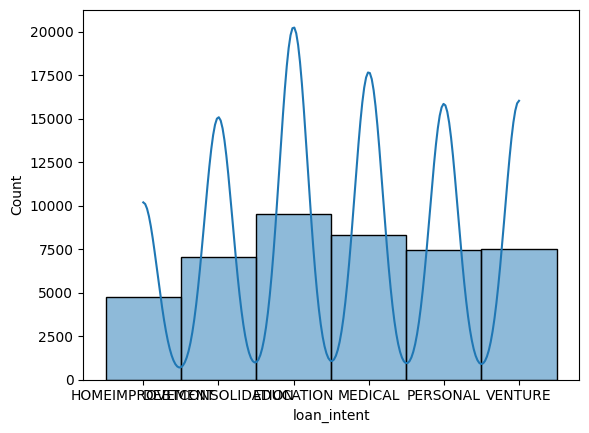

In [41]:
# loan_intent 
sns.histplot(data=X_train, x='loan_intent', kde=True)


In [42]:
X_train['loan_intent'].value_counts(dropna = False)

loan_intent
EDUCATION            9506
MEDICAL              8293
VENTURE              7518
PERSONAL             7437
DEBTCONSOLIDATION    7077
HOMEIMPROVEMENT      4778
Name: count, dtype: int64

In [43]:
X_train = pd.get_dummies(X_train,columns=['loan_intent'],drop_first=True,dtype=int) 
X_test = pd.get_dummies(X_test,columns=['loan_intent'],drop_first=True,dtype=int)

In [44]:
X_train.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
14337,36,10.819798,0.0,C,7200,13.85,0.14,Y,15,0,0,1,0,1,0,0,0
17117,27,10.673619,3.0,C,5000,11.66,0.12,Y,9,0,0,1,0,0,0,0,0
32590,25,11.156265,0.0,A,8000,7.88,0.11,N,3,0,0,0,1,0,0,0,0
55811,39,11.225257,2.0,A,15000,6.54,0.20,N,11,0,0,0,0,0,0,0,0
40120,22,10.727685,5.0,A,4000,7.66,0.09,N,2,0,0,1,0,0,1,0,0


In [45]:
# loan_grade 
X_train['loan_grade'].value_counts(dropna = False)

loan_grade
A    15969
B    15516
C     8444
D     3763
E      783
F      109
G       25
Name: count, dtype: int64

In [46]:
grade_mapping = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}

X_train['loan_grade'] = X_train['loan_grade'].map(grade_mapping)
X_test['loan_grade'] = X_test['loan_grade'].map(grade_mapping)

<Axes: xlabel='loan_amnt', ylabel='Count'>

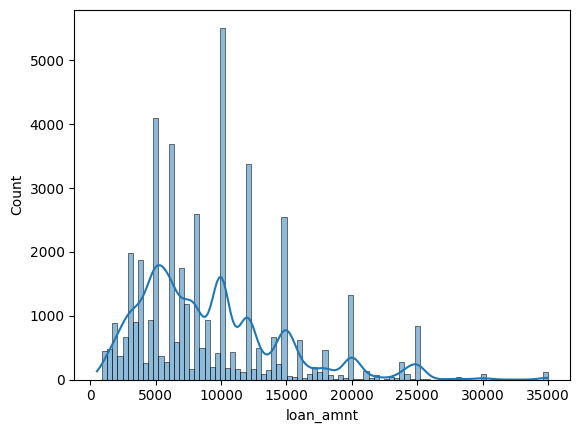

In [47]:
# loan_amnt 
sns.histplot(data=X_train, x='loan_amnt', kde=True)

In [48]:
X_train['loan_amnt'].skew()

np.float64(1.1985980837676982)

In [49]:
#X_train['loan_amnt'] = np.log1p(X_train['loan_amnt'])
#np.float64(-0.4556909554961283)

In [50]:
Q1 = X_train['loan_amnt'].quantile(0.25)
Q3 = X_train['loan_amnt'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

mask = (
    (X_train['loan_amnt'] >= lower_iqr) &
    (X_train['loan_amnt'] <= upper_iqr)
)

X_train = X_train[mask].copy()
y_train = y_train.loc[X_train.index].copy()

In [51]:
# Q1 = X_test['loan_amnt'].quantile(0.25)
# Q3 = X_test['loan_amnt'].quantile(0.75)
# IQR = Q3 - Q1

# lower_iqr = Q1 - 1.5 * IQR
# upper_iqr = Q3 + 1.5 * IQR

# mask = (
#     (X_test['loan_amnt'] >= lower_iqr) &
#     (X_test['loan_amnt'] <= upper_iqr)
# )

# X_test = X_test[mask].copy()
# y_test = y_test.loc[X_test.index].copy()

In [52]:
X_train['loan_amnt'].skew()

np.float64(0.67592528791256)

<Axes: xlabel='loan_int_rate', ylabel='Count'>

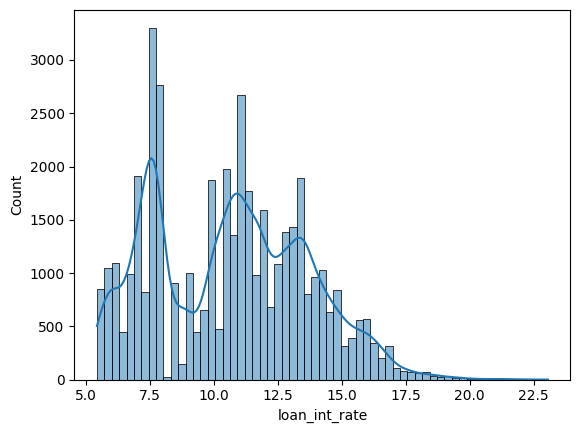

In [53]:
# loan_int_rate 
sns.histplot(data=X_train, x='loan_int_rate', kde=True)

<Axes: xlabel='loan_int_rate'>

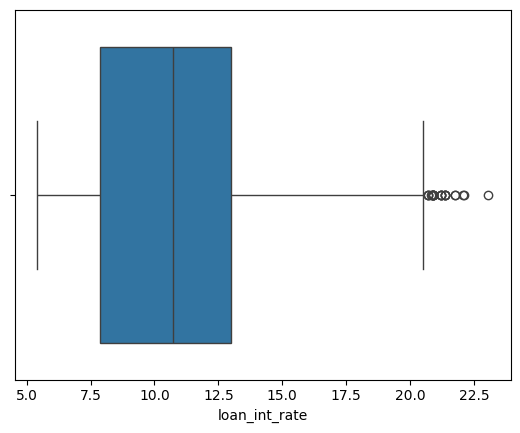

In [54]:
sns.boxplot(x=X_train['loan_int_rate'])

In [55]:
# 23 interest rate is possible , so its not an outkier .  

In [56]:
X_train['loan_int_rate'].skew()

np.float64(0.2037826573755768)

<Axes: xlabel='loan_percent_income', ylabel='Count'>

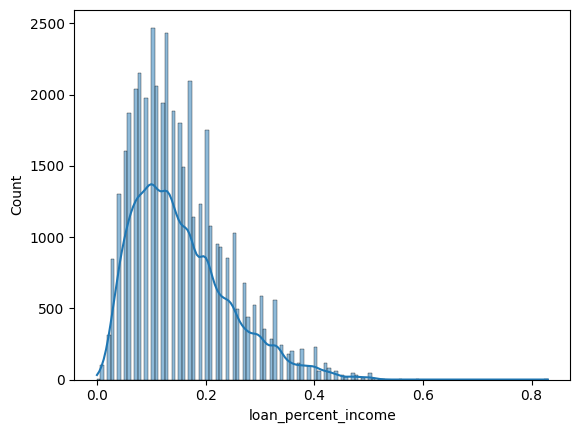

In [57]:
# loan_percent_income 
sns.histplot(data = X_train , x='loan_percent_income' , kde = True)

In [58]:
X_train['loan_percent_income'].skew()

np.float64(0.945252367674419)

In [59]:
X_train['loan_percent_income'] = np.sqrt(X_train['loan_percent_income']) 
X_test['loan_percent_income'] = np.sqrt(X_test['loan_percent_income'])

In [60]:
X_train['loan_percent_income'].skew()


np.float64(0.2570231686460915)

<Axes: xlabel='loan_percent_income', ylabel='Count'>

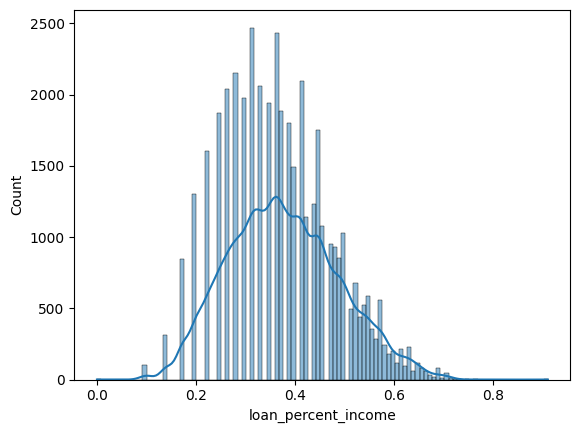

In [61]:
sns.histplot(data = X_train , x='loan_percent_income' , kde = True)

<Axes: xlabel='cb_person_default_on_file', ylabel='Count'>

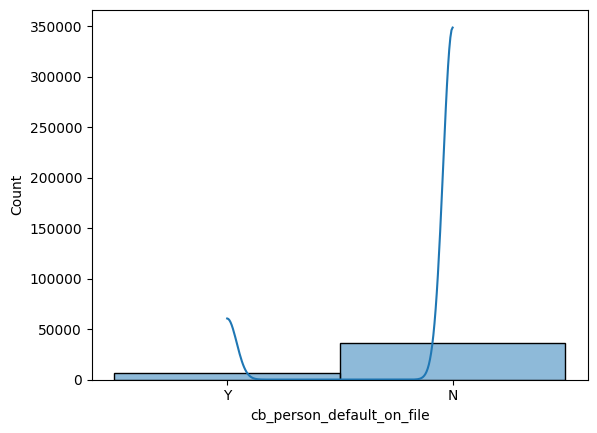

In [62]:
# cb_person_default_on_file 
sns.histplot(data = X_train , x = 'cb_person_default_on_file' , kde=True)

In [63]:
X_train['cb_person_default_on_file'].value_counts(dropna=False)

cb_person_default_on_file
N    36712
Y     6370
Name: count, dtype: int64

In [64]:
grade_mapping = {
    'Y': 1,
    'N': 0
}

X_train['cb_person_default_on_file'] = X_train['cb_person_default_on_file'].map(grade_mapping)
X_test['cb_person_default_on_file'] = X_test['cb_person_default_on_file'].map(grade_mapping)

In [65]:
X_train['cb_person_default_on_file'].value_counts(dropna=False)

cb_person_default_on_file
0    36712
1     6370
Name: count, dtype: int64

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

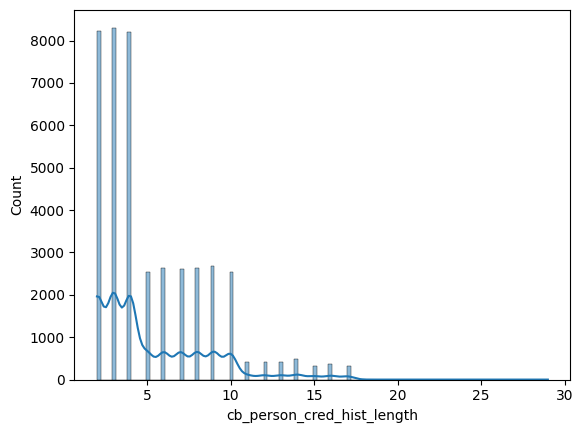

In [66]:
# cb_person_cred_hist_length 
sns.histplot(data = X_train , x='cb_person_cred_hist_length' , kde = True)

In [67]:
X_train['cb_person_cred_hist_length'].skew()

np.float64(1.2583168554806075)

In [68]:
X_train['cb_person_cred_hist_length'] = np.log1p(X_train['cb_person_cred_hist_length'])
X_test['cb_person_cred_hist_length'] = np.log1p(X_test['cb_person_cred_hist_length'])

In [69]:
X_train['cb_person_cred_hist_length'].skew()

np.float64(0.4203669756938759)

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

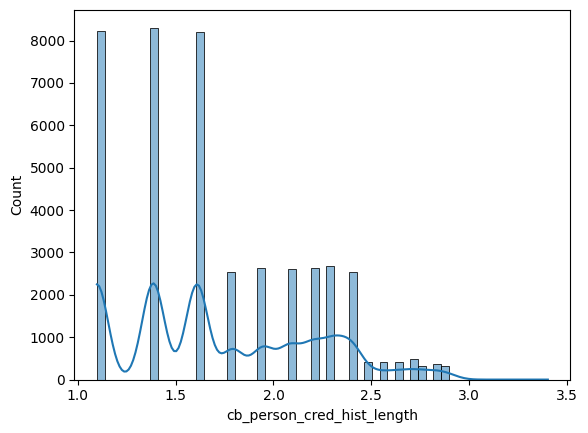

In [70]:
sns.histplot(data = X_train , x='cb_person_cred_hist_length' , kde = True)

In [71]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43082 entries, 14337 to 56422
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   43082 non-null  int64  
 1   person_income                43082 non-null  float64
 2   person_emp_length            43082 non-null  float64
 3   loan_grade                   43082 non-null  int64  
 4   loan_amnt                    43082 non-null  int64  
 5   loan_int_rate                43082 non-null  float64
 6   loan_percent_income          43082 non-null  float64
 7   cb_person_default_on_file    43082 non-null  int64  
 8   cb_person_cred_hist_length   43082 non-null  float64
 9   person_home_ownership_OTHER  43082 non-null  int64  
 10  person_home_ownership_OWN    43082 non-null  int64  
 11  person_home_ownership_RENT   43082 non-null  int64  
 12  loan_intent_EDUCATION        43082 non-null  int64  
 13  loan_intent_HOMEI

In [72]:
X_train.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
14337,36,10.819798,0.0,3,7200,13.85,0.374166,1,2.772589,0,0,1,0,1,0,0,0
17117,27,10.673619,3.0,3,5000,11.66,0.346410,1,2.302585,0,0,1,0,0,0,0,0
32590,25,11.156265,0.0,1,8000,7.88,0.331662,0,1.386294,0,0,0,1,0,0,0,0
55811,39,11.225257,2.0,1,15000,6.54,0.447214,0,2.484907,0,0,0,0,0,0,0,0
40120,22,10.727685,5.0,1,4000,7.66,0.300000,0,1.098612,0,0,1,0,0,1,0,0


In [73]:
X_test.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
4657,23,10.596660,0.0,1,3700,8.00,0.300000,0,1.609438,0,0,1,0,0,1,0,0
56440,25,11.002117,9.0,1,5000,8.59,0.282843,0,1.609438,0,0,0,0,1,0,0,0
42117,32,11.101960,0.0,2,20000,12.53,0.509902,0,1.945910,0,0,1,0,0,1,0,0
10849,22,10.308986,0.0,2,5000,10.59,0.412311,0,1.098612,0,0,1,0,0,0,0,0
39395,27,11.002117,1.0,2,7000,12.21,0.346410,0,2.397895,0,0,1,0,0,1,0,0


In [74]:
# num_cols = [
#     'person_age',
#     'person_income',
#     'person_emp_length',
#     'loan_grade',
#     'loan_amnt',
#     'loan_int_rate',
#     'loan_percent_income',
#     'cb_person_cred_hist_length'
# ]

In [75]:
# from sklearn.preprocessing import StandardScaler


# scaler = StandardScaler()


# # X_train_scaled = X_train.copy()
# # X_test_scaled = X_test.copy()


# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])

# X_train.head()

In [76]:
X_train.shape

(43082, 17)

In [77]:
X_test.shape

(11729, 17)

# Model

In [78]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9533634580953193
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.91      0.74      0.82      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [79]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 5888, number of negative: 37194
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 782
[LightGBM] [Info] Number of data points in the train set: 43082, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.136670 -> initscore=-1.843231
[LightGBM] [Info] Start training from score -1.843231
Accuracy: 0.9509762128058658
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.90      0.73      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9517435416489044
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.92      0.72      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



# TEST DATA

In [81]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv
/kaggle/input/datasets/sushantkr878/loan-approval-prediction-train-data/train (1).csv


In [82]:
test = pd.read_csv('/kaggle/input/datasets/sushantkr878/loan-approval-prediction-test-data/test.csv')

In [83]:
test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [84]:
test_ids = test['id']

In [85]:
test = test.drop('id', axis=1)

In [86]:
test['person_income'] = np.log1p(test['person_income'])

In [87]:
test = pd.get_dummies(
    test,
    columns=['person_home_ownership'],
    drop_first=True,
    dtype=int
)

In [88]:
test = pd.get_dummies(
    test,
    columns=['loan_intent'],
    drop_first=True,
    dtype=int
)

In [89]:
grade_mapping = {
    'A':1,
    'B':2,
    'C':3,
    'D':4,
    'E':5,
    'F':6,
    'G':7
}

test['loan_grade'] = test['loan_grade'].map(grade_mapping)

In [90]:
test['loan_percent_income'] = np.sqrt(test['loan_percent_income'])

In [91]:
mapping = {'Y':1, 'N':0}

test['cb_person_default_on_file'] = (
    test['cb_person_default_on_file'].map(mapping)
)

In [92]:
test['cb_person_cred_hist_length'] = np.log1p(
    test['cb_person_cred_hist_length']
)

In [93]:
test = test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [94]:
test.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,23,11.141876,3.0,6,25000,15.76,0.600000,0,1.098612,0,0,1,0,1,0,0,0
1,26,11.472114,6.0,3,10000,12.68,0.316228,1,1.609438,0,0,0,0,0,0,1,0
2,26,10.308986,5.0,5,4000,17.19,0.360555,1,1.098612,0,0,1,0,0,0,0,1
3,33,10.819798,4.0,1,7000,8.90,0.374166,0,2.079442,0,0,1,0,0,0,0,0
4,26,11.532738,8.0,4,15000,16.32,0.387298,1,1.609438,0,0,0,0,1,0,0,0


In [95]:
# Test with the XGBoost model 
test_pred = xgb.predict(test)

In [96]:
submission = pd.DataFrame({
    'id'    : test_ids,
    'target': test_pred
})

In [97]:
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nSubmission shape: {submission.shape}")

      id  target
0  58645       1
1  58646       0
2  58647       1
3  58648       0
4  58649       0

Submission shape: (39098, 2)
